<a href="https://colab.research.google.com/github/Miranita-ar/Skripsi-Gojek-App-Review/blob/main/Code/(C)_Skripsi_IndoBERT_(Eksperimen_Model_1%262).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install & Import Library

In [ ]:
# =====================================================
# CELL 1 : INSTALL LIBRARY
# =====================================================

!pip install transformers datasets accelerate evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.0 MB/s eta 0:00:00


In [ ]:
# =====================================================
# CELL 2 : IMPORT LIBRARY
# =====================================================

import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import torch

from google.colab import drive

from datasets import load_from_disk

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

print("✅ Library berhasil diimport")

✅ Library berhasil diimport


# Mount Google Drive

In [ ]:
# =====================================================
# CELL 3 : MOUNT GOOGLE DRIVE
# =====================================================

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Skripsi_IndoBERT"

print(PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Skripsi_IndoBERT


# Load Dataset Tokenized - Tokenizer - Class Weight

In [ ]:
# =====================================================
# CELL 4 : LOAD DATASET TOKENIZED
# =====================================================

train_dataset = load_from_disk(
    f"{PROJECT_DIR}/data/tokenized/train_dataset"
)

valid_dataset = load_from_disk(
    f"{PROJECT_DIR}/data/tokenized/valid_dataset"
)

test_dataset = load_from_disk(
    f"{PROJECT_DIR}/data/tokenized/test_dataset"
)

print("Jumlah Data")
print("-"*40)

print("Train :", len(train_dataset))
print("Valid :", len(valid_dataset))
print("Test  :", len(test_dataset))

Jumlah Data
----------------------------------------
Train : 15835
Valid : 1979
Test  : 1980


In [ ]:
# =====================================================
# CELL 5 : LOAD TOKENIZER
# =====================================================

tokenizer = AutoTokenizer.from_pretrained(
    f"{PROJECT_DIR}/data/tokenizer"
)

print("✅ Tokenizer berhasil dimuat")

✅ Tokenizer berhasil dimuat


In [ ]:
# =====================================================
# CELL 6 : LOAD CLASS WEIGHT
# =====================================================

with open(
    f"{PROJECT_DIR}/data/class_weight/class_weight.json",
    "r"
) as f:

    class_weights = json.load(f)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)

print(class_weights)

tensor([1.0779, 8.7101, 0.5109])


# Konfigurasi Eksperimen

1. Exp 1:
- EXPERIMENT_NAME = "exp1_lr2e5_bs8_ep3"
- LEARNING_RATE = 2e-5
- BATCH_SIZE = 8
- NUM_EPOCHS = 3

2. Exp 2:
- EXPERIMENT_NAME = "exp2_lr2e5_bs8_ep4"
- LEARNING_RATE = 2e-5
- BATCH_SIZE = 8
- NUM_EPOCHS = 4

## Exp 1

In [ ]:
# =====================================================
# CELL 7 : KONFIGURASI EKSPERIMEN
# =====================================================

EXPERIMENT_NAME = "exp1_lr2e5_bs8_ep3"

LEARNING_RATE = 2e-5
BATCH_SIZE = 8
NUM_EPOCHS = 3

print(EXPERIMENT_NAME)

exp1_lr2e5_bs8_ep3


In [ ]:
# =====================================================
# CELL 8 : COMPUTE METRICS
# =====================================================

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision, recall, f1, _ = \
        precision_recall_fscore_support(
            labels,
            predictions,
            average=None,
            zero_division=0
        )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        labels,
        predictions,
        average="weighted"
    )

    return {

        "accuracy": accuracy,

        "precision_negatif": precision[0],
        "precision_netral": precision[1],
        "precision_positif": precision[2],

        "recall_negatif": recall[0],
        "recall_netral": recall[1],
        "recall_positif": recall[2],

        "f1_negatif": f1[0],
        "f1_netral": f1[1],
        "f1_positif": f1[2],

        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

In [ ]:
# =====================================================
# CELL 9 : CUSTOM TRAINER
# =====================================================

class CustomTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):

        labels = inputs.get("labels")

        outputs = model(**inputs)

        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(model.device)
        )

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (
            (loss, outputs)
            if return_outputs
            else loss
        )

In [ ]:
# =====================================================
# CELL 10 : LOAD MODEL
# =====================================================

model = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p2",
    num_labels=3
)

print("✅ Model berhasil dimuat")

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model berhasil dimuat


In [ ]:
# =====================================================
# CELL 11 : TRAINING ARGUMENTS
# =====================================================

training_args = TrainingArguments(

    output_dir=
    f"{PROJECT_DIR}/models/{EXPERIMENT_NAME}",

    logging_dir=
    f"{PROJECT_DIR}/logs/{EXPERIMENT_NAME}",

    learning_rate=LEARNING_RATE,

    per_device_train_batch_size=BATCH_SIZE,

    per_device_eval_batch_size=BATCH_SIZE,

    num_train_epochs=NUM_EPOCHS,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="weighted_f1",

    greater_is_better=True,

    save_total_limit=2,

    logging_steps=100,

    report_to="none",

    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# =====================================================
# CELL 12 : TRAINER
# =====================================================

trainer = CustomTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=valid_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print("Trainer siap")

Trainer siap


In [ ]:
# =====================================================
# CELL 13 : TRAINING
# =====================================================

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Negatif,Precision Netral,Precision Positif,Recall Negatif,Recall Netral,Recall Positif,F1 Negatif,F1 Netral,F1 Positif,Macro F1,Weighted F1
1,0.678794,0.771176,0.895907,0.772316,0.000000,0.975124,0.975490,0.000000,0.910922,0.862094,0.000000,0.941930,0.601341,0.881068
2,0.605763,0.715151,0.884790,0.834395,0.185567,0.964115,0.856209,0.236842,0.936483,0.845161,0.208092,0.950098,0.667784,0.889151
3,0.453796,0.920690,0.888327,0.811765,0.208333,0.970660,0.901961,0.197368,0.922541,0.854489,0.202703,0.945989,0.667727,0.889148


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5940, training_loss=0.6666431378836584, metrics={'train_runtime': 1224.3227, 'train_samples_per_second': 38.801, 'train_steps_per_second': 4.852, 'total_flos': 3124800727292160.0, 'train_loss': 0.6666431378836584, 'epoch': 3.0})

# CELL 14 : SIMPAN MODEL TERBAIK

In [ ]:
BEST_MODEL_DIR = \
f"{PROJECT_DIR}/best_model_indobert"

trainer.save_model(
    BEST_MODEL_DIR
)

tokenizer.save_pretrained(
    BEST_MODEL_DIR
)

print("Model terbaik tersimpan")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model terbaik tersimpan


In [ ]:
# =====================================================
# CELL 14 : EVALUASI TEST SET
# =====================================================

test_result = trainer.evaluate(
    test_dataset
)

test_result

Training Loss,Validation Loss,Epoch,Accuracy,Precision Negatif,Precision Netral,Precision Positif,Recall Negatif,Recall Netral,Recall Positif,F1 Negatif,F1 Netral,F1 Positif,Macro F1,Weighted F1
0.453796,0.753691,3,0.891414,0.853859,0.153846,0.953596,0.848287,0.160000,0.954334,0.851064,0.156863,0.953965,0.653964,0.891914


{'eval_loss': 0.7536909580230713,
 'eval_accuracy': 0.8914141414141414,
 'eval_precision_negatif': 0.8538587848932676,
 'eval_precision_netral': 0.15384615384615385,
 'eval_precision_positif': 0.9535962877030162,
 'eval_recall_negatif': 0.8482871125611745,
 'eval_recall_netral': 0.16,
 'eval_recall_positif': 0.9543343653250774,
 'eval_f1_negatif': 0.851063829787234,
 'eval_f1_netral': 0.1568627450980392,
 'eval_f1_positif': 0.9539651837524178,
 'eval_macro_f1': 0.6539639195458969,
 'eval_weighted_f1': 0.8919140661363895}

In [ ]:
# =====================================================
# CELL 15 : PREDIKSI TEST SET
# =====================================================

predictions = trainer.predict(
    test_dataset
)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

In [ ]:
# =====================================================
# CELL 16 : CLASSIFICATION REPORT
# =====================================================

report = classification_report(

    y_true,

    y_pred,

    target_names=[
        "Negatif",
        "Netral",
        "Positif"
    ],

    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Negatif,0.853859,0.848287,0.851064,613.000000
Netral,0.153846,0.160000,0.156863,75.000000
Positif,0.953596,0.954334,0.953965,1292.000000
accuracy,0.891414,0.891414,0.891414,0.891414
macro avg,0.653767,0.654207,0.653964,1980.000000
weighted avg,0.892424,0.891414,0.891914,1980.000000


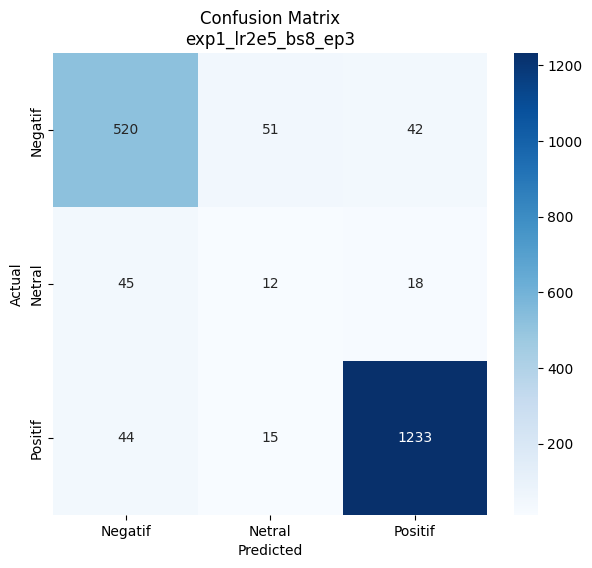

Confusion Matrix tersimpan di:
/content/drive/MyDrive/Skripsi_IndoBERT/results/exp1_lr2e5_bs8_ep3/confusion_matrix.png


In [ ]:
# =====================================================
# CELL 17 : CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Negatif",
        "Netral",
        "Positif"
    ],

    yticklabels=[
        "Negatif",
        "Netral",
        "Positif"
    ]
)

plt.title(
    f"Confusion Matrix\n{EXPERIMENT_NAME}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

CONFUSION_PATH = \
f"{RESULT_DIR}/confusion_matrix.png"

plt.savefig(
    CONFUSION_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Confusion Matrix tersimpan di:\n{CONFUSION_PATH}"
)


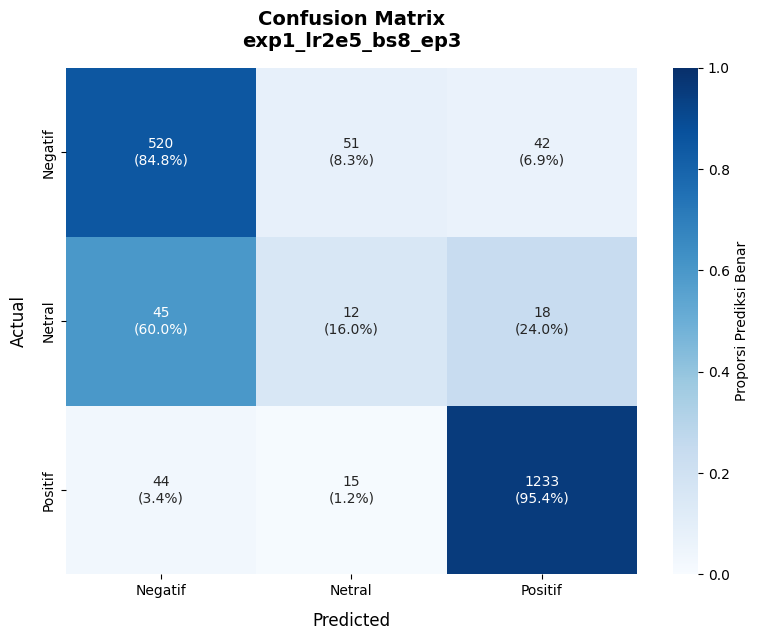

Confusion Matrix tersimpan di:
/content/drive/MyDrive/Skripsi_IndoBERT/results/exp1_lr2e5_bs8_ep3/confusion_matrix.png


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# =====================================================
# CELL 17 : CONFUSION MATRIX (MODIFIED)
# =====================================================

cm = confusion_matrix(y_true, y_pred)

# Hitung normalisasi (persentase per baris/aktual)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Membuat label kustom: "Jumlah Asli \n (Persentase%)"
labels = [
    [f"{value}\n({percent:.1%})" for value, percent in zip(row_val, row_per)]
    for row_val, row_per in zip(cm, cm_norm)
]
labels = np.asarray(labels)

plt.figure(figsize=(8, 6.5))

# Gunakan cm_norm untuk warna heatmap agar diagonal utama merata highlight-nya
sns.heatmap(
    cm_norm,
    annot=labels,       # Menggunakan label gabungan angka + %
    fmt="",             # Kosongkan format karena string sudah diformat di atas
    cmap="Blues",
    vmin=0,             # Batas bawah warna (0%)
    vmax=1,             # Batas atas warna (100%)
    xticklabels=["Negatif", "Netral", "Positif"],
    yticklabels=["Negatif", "Netral", "Positif"],
    cbar_kws={'label': 'Proporsi Prediksi Benar'} # Label pada colorbar
)

plt.title(f"Confusion Matrix\n{EXPERIMENT_NAME}", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Predicted", fontsize=12, labelpad=10)
plt.ylabel("Actual", fontsize=12, labelpad=10)
plt.tight_layout()

plt.savefig(
    CONFUSION_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Confusion Matrix tersimpan di:\n{CONFUSION_PATH}"
)

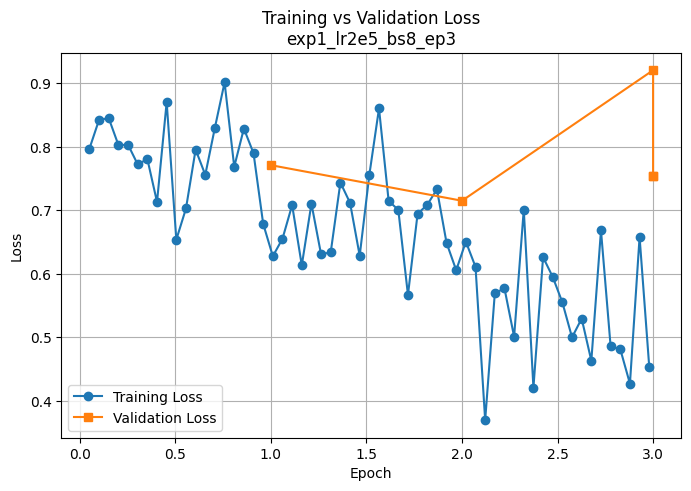

✅ Loss curve berhasil disimpan


In [ ]:
# =====================================================
# CELL XX : LOSS CURVE
# =====================================================

log_history = trainer.state.log_history

train_loss = []
eval_loss = []
epochs_train = []
epochs_eval = []

for log in log_history:

    if "loss" in log and "epoch" in log:

        train_loss.append(log["loss"])
        epochs_train.append(log["epoch"])

    if "eval_loss" in log and "epoch" in log:

        eval_loss.append(log["eval_loss"])
        epochs_eval.append(log["epoch"])

plt.figure(figsize=(8,5))

plt.plot(
    epochs_train,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_eval,
    eval_loss,
    marker="s",
    label="Validation Loss"
)

plt.title(
    f"Training vs Validation Loss\n{EXPERIMENT_NAME}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.savefig(
    f"{RESULT_DIR}/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Loss curve berhasil disimpan")

In [ ]:
loss_df = pd.DataFrame({

    "epoch_train":
    pd.Series(epochs_train),

    "train_loss":
    pd.Series(train_loss)
})

loss_df.to_csv(

    f"{RESULT_DIR}/training_loss.csv",

    index=False
)

In [ ]:
eval_loss_df = pd.DataFrame({

    "epoch_eval":
    pd.Series(epochs_eval),

    "eval_loss":
    pd.Series(eval_loss)
})

eval_loss_df.to_csv(

    f"{RESULT_DIR}/validation_loss.csv",

    index=False
)

In [ ]:
# =====================================================
# CELL 18 : SIMPAN HASIL
# =====================================================

RESULT_DIR = \
f"{PROJECT_DIR}/results/{EXPERIMENT_NAME}"

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

# Metrics

with open(
    f"{RESULT_DIR}/metrics.json",
    "w"
) as f:

    json.dump(
        test_result,
        f,
        indent=4
    )

# Classification report

report_df.to_csv(
    f"{RESULT_DIR}/classification_report.csv"
)

# Prediksi

prediction_df = pd.DataFrame({

    "actual": y_true,

    "prediction": y_pred
})

prediction_df.to_csv(

    f"{RESULT_DIR}/predictions_test.csv",

    index=False
)

prediction_with_text_df = pd.DataFrame({

    "text": test_dataset["text"],
    "actual": y_true,
    "prediction": y_pred
})

prediction_with_text_df.to_csv(

    f"{RESULT_DIR}/predictions_with_text.csv",

    index=False
)

print("✅ Predictions with text berhasil disimpan")

print("✅ Hasil berhasil disimpan")

✅ Predictions with text berhasil disimpan
✅ Hasil berhasil disimpan


In [ ]:
# =====================================================
# CELL 19 : UPDATE SUMMARY
# =====================================================

summary_file = \
f"{PROJECT_DIR}/results/summary_experiments.csv"

summary_row = pd.DataFrame([{

    "experiment":
    EXPERIMENT_NAME,

    "learning_rate":
    LEARNING_RATE,

    "batch_size":
    BATCH_SIZE,

    "epochs":
    NUM_EPOCHS,

    "eval_loss":
    test_result["eval_loss"],

    "accuracy":
    test_result["eval_accuracy"],

    "macro_f1":
    test_result["eval_macro_f1"],

    "weighted_f1":
    test_result["eval_weighted_f1"]

}])

if os.path.exists(summary_file):

    old_df = pd.read_csv(
        summary_file
    )

    summary_row = pd.concat(

        [old_df, summary_row],

        ignore_index=True
    )

summary_row.to_csv(

    summary_file,

    index=False
)

print("✅ Summary berhasil diperbarui")

summary_row

✅ Summary berhasil diperbarui


,experiment,learning_rate,batch_size,epochs,accuracy,precision_negatif,precision_netral,precision_positif,recall_negatif,recall_netral,recall_positif,f1_negatif,f1_netral,f1_positif,macro_f1,weighted_f1,eval_loss
0,exp3_lr3e5_bs8_ep3,0.00003,8,3,0.905556,0.854071,0.169492,0.966142,0.907015,0.133333,0.949690,0.879747,0.149254,0.957845,0.662282,0.903038,NaN
1,exp5_lr2e5_bs16_ep3,0.00002,16,3,0.895455,0.842025,0.150000,0.971154,0.895595,0.160000,0.938080,0.867984,0.154839,0.954331,0.659051,0.897314,NaN
2,exp6_lr2e5_bs16_ep4,0.00002,16,4,0.898485,0.843411,0.158730,0.963050,0.887439,0.133333,0.948142,0.864865,0.144928,0.955538,0.655110,0.896761,NaN
3,exp1_lr2e5_bs8_ep3,0.00002,8,3,0.891414,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.653964,0.891914,0.753691
4,exp1_lr2e5_bs8_ep3,0.00002,8,3,0.891414,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.653964,0.891914,0.753691


In [ ]:
# =====================================================
# CELL 21 : RINGKASAN AKHIR
# =====================================================

print("\n" + "="*70)

print(
    f"EKSPERIMEN {EXPERIMENT_NAME} SELESAI"
)

print("="*70)

for k,v in metrics_summary.items():

    print(
        f"{k:20s}: {v:.4f}"
    )

print("\nFolder hasil:")

print(RESULT_DIR)

print("="*70)


EKSPERIMEN exp1_lr2e5_bs8_ep3 SELESAI


NameError: name 'metrics_summary' is not defined

# ulasan + prediksi

In [ ]:
prediction_df = pd.DataFrame({

    "text": test_dataset["text"],
    "actual": y_true,
    "prediction": y_pred
})

In [ ]:
prediction_df = pd.DataFrame({

    "text": test_dataset["text"],
    "actual": y_true,
    "prediction": y_pred
})

## Exp 2

In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Skripsi_IndoBERT"

with open(f"{PROJECT_DIR}/data/metrics.py", "w") as f:
    f.write("""
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average=None,
        zero_division=0
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average='macro'
    )

    weighted_f1 = f1_score(
        labels,
        predictions,
        average='weighted'
    )

    return {
        'accuracy': accuracy,

        'precision_negatif': precision[0],
        'precision_netral': precision[1],
        'precision_positif': precision[2],

        'recall_negatif': recall[0],
        'recall_netral': recall[1],
        'recall_positif': recall[2],

        'f1_negatif': f1[0],
        'f1_netral': f1[1],
        'f1_positif': f1[2],

        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1
    }
""")

print("✅ metrics.py berhasil dibuat")

✅ metrics.py berhasil dibuat


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Skripsi_IndoBERT"

with open(f"{PROJECT_DIR}/data/custom_trainer.py", "w") as f:
    f.write("""
import torch
from transformers import Trainer

class CustomTrainer(Trainer):

    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(self.args.device)

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):
        labels = inputs.get("labels")

        outputs = model(**inputs)

        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(
            weight=self.class_weights
        )

        loss = loss_fct(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss
""")

print("✅ custom_trainer.py berhasil dibuat")

✅ custom_trainer.py berhasil dibuat


In [ ]:
import sys

if f"{PROJECT_DIR}/data" not in sys.path:
    sys.path.append(f"{PROJECT_DIR}/data")

from custom_trainer import CustomTrainer
from metrics import compute_metrics

print("✅ Import berhasil")

✅ Import berhasil


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/Skripsi_IndoBERT/data"):
    level = root.replace("/content/drive/MyDrive/Skripsi_IndoBERT/data","").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

data/
    tokenizer/
    split/
    tokenized/
        train_dataset/
        valid_dataset/
        test_dataset/
    class_weight/
    __pycache__/


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Skripsi_IndoBERT"

print(PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Skripsi_IndoBERT


In [ ]:
train_dataset = load_from_disk(
    f"{PROJECT_DIR}/data/tokenized/train_dataset"
)

valid_dataset = load_from_disk(
    f"{PROJECT_DIR}/data/tokenized/valid_dataset"
)

test_dataset = load_from_disk(
    f"{PROJECT_DIR}/data/tokenized/test_dataset"
)

tokenizer = AutoTokenizer.from_pretrained(
    f"{PROJECT_DIR}/data/tokenizer"
)

print("="*50)
print("Jumlah Data")
print("-"*50)

print("Train :", len(train_dataset))
print("Valid :", len(valid_dataset))
print("Test  :", len(test_dataset))

Jumlah Data
--------------------------------------------------
Train : 15835
Valid : 1979
Test  : 1980


In [ ]:
with open(
    f"{PROJECT_DIR}/data/class_weight/class_weight.json",
    "r"
) as f:
    class_weight_list = json.load(f)

class_weights = torch.tensor(class_weight_list)

print(class_weights)

tensor([1.0779, 8.7101, 0.5109])


In [ ]:
def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.argmax(
        predictions,
        axis=1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average=None,
            zero_division=0
        )
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        labels,
        predictions,
        average="weighted"
    )

    return {

        "accuracy": accuracy,

        "precision_negatif": precision[0],
        "precision_netral": precision[1],
        "precision_positif": precision[2],

        "recall_negatif": recall[0],
        "recall_netral": recall[1],
        "recall_positif": recall[2],

        "f1_negatif": f1[0],
        "f1_netral": f1[1],
        "f1_positif": f1[2],

        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

In [ ]:
class CustomTrainer(Trainer):

    def __init__(
        self,
        class_weights,
        *args,
        **kwargs
    ):

        super().__init__(*args, **kwargs)

        self.class_weights = (
            class_weights.to(self.args.device)
        )

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):

        labels = inputs.get("labels")

        outputs = model(**inputs)

        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(
            weight=self.class_weights
        )

        loss = loss_fct(
            logits.view(
                -1,
                self.model.config.num_labels
            ),
            labels.view(-1)
        )

        return (
            (loss, outputs)
            if return_outputs
            else loss
        )

print("trainer siap")

trainer siap


In [ ]:
EXPERIMENT_NAME = "exp2_lr2e5_bs8_epoch4"

LEARNING_RATE = 2e-5

BATCH_SIZE = 8

EPOCHS = 4

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p2",
    num_labels=3
)

print("✅ Model berhasil dimuat")

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model berhasil dimuat


In [ ]:
training_args = TrainingArguments(

    output_dir=
    f"{PROJECT_DIR}/models/{EXPERIMENT_NAME}",

    logging_dir=
    f"{PROJECT_DIR}/logs/{EXPERIMENT_NAME}",

    num_train_epochs=EPOCHS,

    per_device_train_batch_size=BATCH_SIZE,

    per_device_eval_batch_size=BATCH_SIZE,

    learning_rate=LEARNING_RATE,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="weighted_f1",

    greater_is_better=True,

    save_total_limit=1,

    logging_steps=100,

    report_to="none",

    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = CustomTrainer(

    class_weights=class_weights,

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=valid_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print("trainer siap")

trainer siap


In [ ]:
train_result = trainer.train()

train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision Negatif,Precision Netral,Precision Positif,Recall Negatif,Recall Netral,Recall Positif,F1 Negatif,F1 Netral,F1 Positif,Macro F1,Weighted F1
1,0.665646,0.794740,0.900455,0.792963,0.000000,0.964516,0.957516,0.000000,0.926414,0.867506,0.000000,0.945081,0.604196,0.884797
2,0.630392,0.673093,0.893886,0.843014,0.196429,0.949456,0.877451,0.144737,0.945778,0.859888,0.166667,0.947614,0.658056,0.890494
3,0.565311,0.823338,0.885801,0.836957,0.161616,0.969256,0.880719,0.210526,0.927963,0.858280,0.182857,0.948160,0.663099,0.890975


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision Negatif,Precision Netral,Precision Positif,Recall Negatif,Recall Netral,Recall Positif,F1 Negatif,F1 Netral,F1 Positif,Macro F1,Weighted F1
1,0.665646,0.794740,0.900455,0.792963,0.000000,0.964516,0.957516,0.000000,0.926414,0.867506,0.000000,0.945081,0.604196,0.884797
2,0.630392,0.673093,0.893886,0.843014,0.196429,0.949456,0.877451,0.144737,0.945778,0.859888,0.166667,0.947614,0.658056,0.890494
3,0.565311,0.823338,0.885801,0.836957,0.161616,0.969256,0.880719,0.210526,0.927963,0.858280,0.182857,0.948160,0.663099,0.890975
4,0.347011,1.110539,0.888327,0.824773,0.191176,0.959968,0.892157,0.171053,0.928737,0.857143,0.180556,0.944094,0.660598,0.887883


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=7920, training_loss=0.6065297873333247, metrics={'train_runtime': 1657.5265, 'train_samples_per_second': 38.214, 'train_steps_per_second': 4.778, 'total_flos': 4166400969722880.0, 'train_loss': 0.6065297873333247, 'epoch': 4.0})

In [ ]:
eval_result = trainer.evaluate()

eval_result

Training Loss,Validation Loss,Epoch,Accuracy,Precision Negatif,Precision Netral,Precision Positif,Recall Negatif,Recall Netral,Recall Positif,F1 Negatif,F1 Netral,F1 Positif,Macro F1,Weighted F1
0.347011,0.823338,4,0.885801,0.836957,0.161616,0.969256,0.880719,0.210526,0.927963,0.858280,0.182857,0.948160,0.663099,0.890975


{'eval_loss': 0.8233375549316406,
 'eval_accuracy': 0.8858009095502779,
 'eval_precision_negatif': 0.8369565217391305,
 'eval_precision_netral': 0.16161616161616163,
 'eval_precision_positif': 0.9692556634304207,
 'eval_recall_negatif': 0.880718954248366,
 'eval_recall_netral': 0.21052631578947367,
 'eval_recall_positif': 0.9279628195197521,
 'eval_f1_negatif': 0.85828025477707,
 'eval_f1_netral': 0.18285714285714286,
 'eval_f1_positif': 0.9481598733676296,
 'eval_macro_f1': 0.6630990903339474,
 'eval_weighted_f1': 0.8909747626570589}

In [ ]:
metrics_file = (
    f"{PROJECT_DIR}/results/"
    f"{EXPERIMENT_NAME}_metrics.txt"
)

with open(metrics_file, "w") as f:

    f.write(f"{EXPERIMENT_NAME}\n\n")

    for key, value in eval_result.items():

        f.write(
            f"{key}: {value}\n"
        )

print("✅ metrics tersimpan")

✅ metrics tersimpan


In [ ]:
# =====================================================
# CELL 16 : CLASSIFICATION REPORT
# =====================================================

report = classification_report(

    y_true,

    y_pred,

    target_names=[
        "Negatif",
        "Netral",
        "Positif"
    ],

    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Negatif,0.852381,0.876020,0.864039,613.000000
Netral,0.182927,0.200000,0.191083,75.000000
Positif,0.967666,0.949690,0.958594,1292.000000
accuracy,0.898485,0.898485,0.898485,0.898485
macro avg,0.667658,0.675237,0.671238,1980.000000
weighted avg,0.902249,0.898485,0.900247,1980.000000


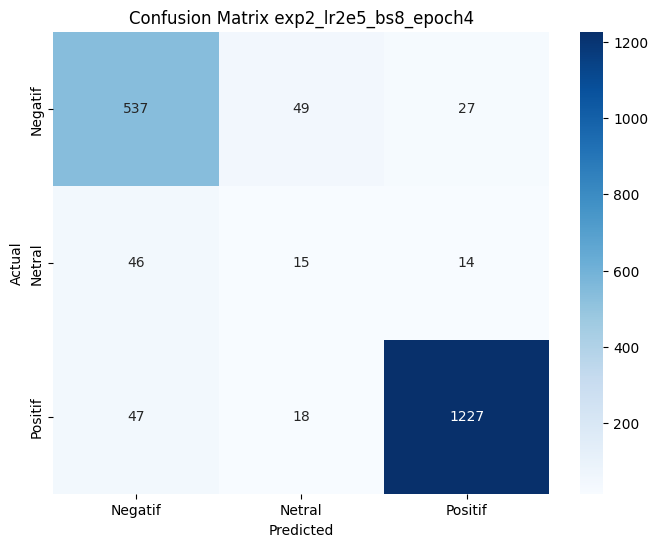

✅ confusion matrix tersimpan


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

predictions = trainer.predict(
    test_dataset
)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Negatif",
        "Netral",
        "Positif"
    ],
    yticklabels=[
        "Negatif",
        "Netral",
        "Positif"
    ]
)

plt.title(
    f"Confusion Matrix {EXPERIMENT_NAME}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

save_path = (
    f"{PROJECT_DIR}/results/"
    f"confusion_matrix_{EXPERIMENT_NAME}.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ confusion matrix tersimpan")

In [ ]:
# ==========================================
# HAPUS CACHE COLAB
# ==========================================

import shutil

cache_paths = [
    "/root/.cache",
    "/tmp",
]

for path in cache_paths:
    if os.path.exists(path):
        size_mb = shutil.disk_usage(path).used / (1024 ** 2)
        if size_mb > 100:
            print(f"⚠️ {path}: {size_mb:.2f} MB")
            confirm = input(f"Hapus cache di {path}? (y/n): ")
            if confirm.lower() == 'y':
                shutil.rmtree(path)
                print(f"✅ {path} telah dihapus.")
        else:
            print(f"✅ {path}: {size_mb:.2f} MB (aman)")

⚠️ /root/.cache: 53041.52 MB
Hapus cache di /root/.cache? (y/n): y
✅ /root/.cache telah dihapus.
⚠️ /tmp: 52091.76 MB
Hapus cache di /tmp? (y/n): y
✅ /tmp telah dihapus.
